In [1]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
#import cartopy.crs as crs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from cartopy.feature import NaturalEarthFeature
import cartopy.crs as ccrs
from datetime import datetime, timedelta
from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_specific_humidity, wind_speed, specific_humidity_from_mixing_ratio
import pyart
from wrf import getvar
import haversine
from metpy.interpolate import log_interpolate_1d, interpolate_1d
from pyproj import Geod


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
g = Geod(ellps='sphere')

In [3]:
#Basic settings for the UAS transects
wspd_thresh = 20 #wind speed cutoff for UAS ops, in m/s
drone_spd = 30 #UAS cruising speed, in m/s
begin_time1 = 10800 #Baseline time (in seconds since 0 UTC)
ascent_rate = 3 #Ascent / descent rate for the profiles (in m/s)
z_res = 50 #profile vertical resolution (in m)
prof_top = 100 #Profile top / UAS cruising altitude (in m)
x_int = 150 #interval between obs along transects (in s)
delay = 60 #delay in seconds between profiles and transects

#Datetims start info
dt = datetime(2022,9,15,10)
#dt = datetime(2022,7,19,10)
#dt = datetime(2021,6,4,10)

#Start day
st_day = 154024
#st_day = 153966
#st_day = 153556

ncfile1 = Dataset('/glade/work/mawilson/DART_mpd/observations/utilities/threed_sphere/obs_epoch_100mIOP4.nc')
#ncfile1 = Dataset('/glade/work/mawilson/DART_mpd/observations/utilities/threed_sphere/obs_epoch_100mJUNE.nc')

location = ncfile1.variables['location'][:]
qc = ncfile1.variables['qc'][:]
obstype = ncfile1.variables['obs_type'][:]
obstypemd = ncfile1.variables['ObsTypesMetaData'][:]
obs_val = ncfile1.variables['observations'][:]
which_vert = ncfile1.variables['which_vert'][:]

print(obstype)
qc_new = []
for i in range(len(qc)):
    qc_d = qc[i][0]
    qc_new.append(qc_d)
qc_new = np.asarray(qc_new)

otype1 = 142
loc_T = location[obstype==otype1, :]
qc_T = qc_new[obstype==otype1]
obs_T = obs_val[obstype==otype1, :]
lons_T = loc_T[:,0]
lats_T = loc_T[:,1]

lons_T[lons_T > 180] = lons_T[lons_T > 180] - 360

prof_lons = lons_T[np.unique(lons_T, return_index=True)[1]]
prof_lats = lats_T[np.unique(lons_T, return_index=True)[1]]

[142 105 106 ...  26  27  28]


In [4]:

#Make an array where the starting point for each route is CVG and the end is every other ASOS in the domain
lons_start = np.asarray([-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55])
lats_start = np.asarray([39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21])
lons_end = np.asarray([-84.93, -84.55, -84.09, -84.15, -84.52, -84.94, -85.21, -85.29])
lats_end = np.asarray([39.41, 39.48, 39.47, 38.92, 38.86, 38.95, 39.19, 38.86])

lons_start = np.asarray([-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55])
lats_start = np.asarray([39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21])
lons_end = np.asarray([-84.93, -84.55, -84.09, -84.15, -84.52, -84.94, -85.21, -85.29,
                      -85.26000214,-84.77999878,-84.66999817,-84.51999664,-84.41999817,-84.40000153,-84.25,-84.23000336,-84.22000122])
lats_end = np.asarray([39.41, 39.48, 39.47, 38.92, 38.86, 38.95, 39.19, 38.86,
                      39.34999847,39.25,39.04000092,39.36000061,39.09999847,39.52999878,39.45999908,39.59999847,39.08000183])

# lons_start = np.asarray([-84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229])
# lats_start = np.asarray([39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456])
# lons_end = np.asarray([-84.41583, -84.2102, -84.7743, -84.25184, -84.78436, -85.25843, -85.4655, -83.77917, -84.39530, -83.7434])
# lats_end = np.asarray([39.10583, 39.0784, 39.2589, 39.46217, 39.50225, 39.34313, 38.7589, 39.42833, 39.53100, 38.5418])
st_ids = ['Site 1', 'Site 2', 'Site 3', 'Site 4', 'Site 5', 'Site 6', 'Site 7', 'Site 8',
          'Site 9', 'Site 10', 'Site 11', 'Site 12', 'Site 13', 'Site 14', 'Site 15', 'Site 16', 'Site 17']
#Get distance between the points

#Make a definition for this section
#Inputs: start and end point, obs_interval (in seconds), drone speed (in m/s)
#Outputs: lat / lons and times (since transect start, in seconds) for UAS transect
def get_transect_points(lat_d, lon_d, lat_c, lon_c, ob_int, drone_spd, start_time, height):
    points=[]
    station=[]
    points.append((lat_d,lon_d))
    station.append((lat_c,lon_c))
    dist = haversine.haversine_vector(station,points)
    #Get the bearing between the cities
    distance_track = g.inv(lon_d, lat_d,
                           lon_c, lat_c)
    bearing = distance_track[0]
    if bearing < 0:
        bearing = 360 + bearing
    print(dist)
    print((dist*1000)/drone_spd)
    print(((dist*1000)/drone_spd)/3600)
    print(((dist*1000)/drone_spd)/ob_int)
    print(int(((dist*1000)/drone_spd)/ob_int))
    
    #Extrapolate forward to get points along the path every 5 minutes
    path_lat = []
    path_lon = []
    lond1 = lon_d
    latd1 = lat_d
    time_path = []
    time_i = start_time
    for i in range(int(((dist*1000)/drone_spd)/ob_int)):
        prj_lon, prj_lat, prj_bear = g.fwd(lond1, latd1, bearing, drone_spd*ob_int)
        path_lat.append(prj_lat)
        path_lon.append(prj_lon)
        time_i = time_i + ob_int
        time_path.append(time_i)
        lond1 = prj_lon
        latd1 = prj_lat
    path_z = np.zeros((len(path_lon)))
    path_z[:] = height
    return path_lon, path_lat, time_path, path_z

#Make a definition that creates the takeoff profile

def takeoff_profile(ascent_rate, resolution, top, start_time, prof_lat, prof_lon):
    uas_z = np.arange(0, top+resolution, resolution)
    #uas_time = np.arange(0, ((len(uas_z)*resolution)/ascent_rate)+(resolution/ascent_rate), resolution/ascent_rate)+start_time
    uas_time = np.arange(0, ((len(uas_z)*resolution)/ascent_rate), resolution/ascent_rate)+start_time
    uas_lat = np.zeros((len(uas_z)))
    uas_lon = np.zeros((len(uas_z)))
    uas_lat[:] = prof_lat
    uas_lon[:] = prof_lon
    print(len(uas_time), 'T')
    print(len(uas_lon), 'L')
    return uas_z, uas_time, uas_lat, uas_lon

#Make a definition for the landing profile

def landing_profile(ascent_rate, resolution, top, start_time, prof_lat, prof_lon):
    uas_z = np.arange(top-resolution, 0, resolution*-1)
    uas_time = np.arange(resolution/ascent_rate, ((len(uas_z)*resolution)/ascent_rate)+(resolution/ascent_rate), resolution/ascent_rate)+start_time
    uas_lat = np.zeros((len(uas_z)))
    uas_lon = np.zeros((len(uas_z)))
    uas_lat[:] = prof_lat
    uas_lon[:] = prof_lon
    return uas_z, uas_time, uas_lat, uas_lon

#Now run all of them

all_lons = []
all_lats = []
all_times = []
all_zs = []

for begin_time in [begin_time1, begin_time1+(2*3600), begin_time1+(4*3600), begin_time1+(6*3600)]:
    for i in range(len(lons_start)):
        tk_z, tk_time, tk_lat, tk_lon = takeoff_profile(ascent_rate, z_res, prof_top, begin_time, lats_start[i], lons_start[i])
        path_lon, path_lat, time_path, z_path = get_transect_points(lats_start[i], lons_start[i], lats_end[i], lons_end[i], x_int, drone_spd, tk_time[-1]+delay, prof_top)
        #MW 11/12/24 removing landing profiles since they're typically not used
        #ln_z, ln_time, ln_lat, ln_lon = landing_profile(ascent_rate, z_res, prof_top, time_path[-1]+delay, lats_end[i], lons_end[i])
    
        path_lon1 = np.concatenate([tk_lon, path_lon])
        path_lat1 = np.concatenate([tk_lat, path_lat])
        path_time1 = np.concatenate([tk_time, time_path])
        path_z1 = np.concatenate([tk_z, z_path])
        
        all_lons.append(path_lon1)
        all_lats.append(path_lat1)
        all_times.append(path_time1)
        all_zs.append(path_z1)
    
    for i in range(len(lons_start)):
        tk_z, tk_time, tk_lat, tk_lon = takeoff_profile(ascent_rate, z_res, prof_top, begin_time+3600, lats_end[i], lons_end[i])
        path_lon, path_lat, time_path, z_path = get_transect_points(lats_end[i], lons_end[i], lats_start[i], lons_start[i], x_int, drone_spd, tk_time[-1]+delay, prof_top)
        #MW 11/12/24 removing landing profiles since they're typically not used
        #ln_z, ln_time, ln_lat, ln_lon = landing_profile(ascent_rate, z_res, prof_top, time_path[-1]+delay, lats_end[i], lons_end[i])
    
        path_lon1 = np.concatenate([tk_lon, path_lon])
        path_lat1 = np.concatenate([tk_lat, path_lat])
        path_time1 = np.concatenate([tk_time, time_path])
        path_z1 = np.concatenate([tk_z, z_path])
        
        all_lons.append(path_lon1)
        all_lats.append(path_lat1)
        all_times.append(path_time1)
        all_zs.append(path_z1)
    
all_lons1 = np.concatenate(all_lons)
all_lats1 = np.concatenate(all_lats)
all_times1 = np.concatenate(all_times)
all_zs1 = np.concatenate(all_zs)


3 T
3 L
[39.54009533]
[1318.00317753]
[0.36611199]
[8.78668785]
8
3 T
3 L
[30.02267166]
[1000.7557221]
[0.2779877]
[6.67170481]
6
3 T
3 L
[48.9973507]
[1633.24502344]
[0.45367917]
[10.88830016]
10
3 T
3 L
[47.24869554]
[1574.95651815]
[0.43748792]
[10.49971012]
10
3 T
3 L
[39.00444108]
[1300.14803594]
[0.36115223]
[8.66765357]
8
3 T
3 L
[44.37412161]
[1479.1373871]
[0.4108715]
[9.86091591]
9
3 T
3 L
[56.9155478]
[1897.18492678]
[0.52699581]
[12.64789951]
12
3 T
3 L
[74.83140606]
[2494.38020215]
[0.69288339]
[16.62920135]
16
3 T
3 L
[63.06255346]
[2102.08511543]
[0.58391253]
[14.01390077]
14
3 T
3 L
[20.30369119]
[676.78970623]
[0.18799714]
[4.51193137]
4
3 T
3 L
[21.55166716]
[718.38890525]
[0.19955247]
[4.78925937]
4
3 T
3 L
[16.87803586]
[562.60119534]
[0.15627811]
[3.75067464]
3
3 T
3 L
[16.59108116]
[553.03603858]
[0.15362112]
[3.68690692]
3
3 T
3 L
[37.84645531]
[1261.5485104]
[0.35043014]
[8.4103234]
8
3 T
3 L
[37.92712668]
[1264.23755585]
[0.3511771]
[8.42825037]
8
3 T
3 L
[51.3

/glade/derecho/scratch/mawilson/tmp/ipykernel_125605/322109410.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(int(((dist*1000)/drone_spd)/ob_int))
/glade/derecho/scratch/mawilson/tmp/ipykernel_125605/322109410.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range(int(((dist*1000)/drone_spd)/ob_int)):


In [5]:
#print(distance_track)

In [6]:
#print(prj_lon, prj_lat)

In [7]:
# print(path_z1)
# print(path_time1)
print(all_times1)

[10800.         10816.66666667 10833.33333333 ... 36843.33333333
 36993.33333333 37143.33333333]


In [8]:
#print(lon_c, lat_c)

In [9]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

# LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
# UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

# #Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

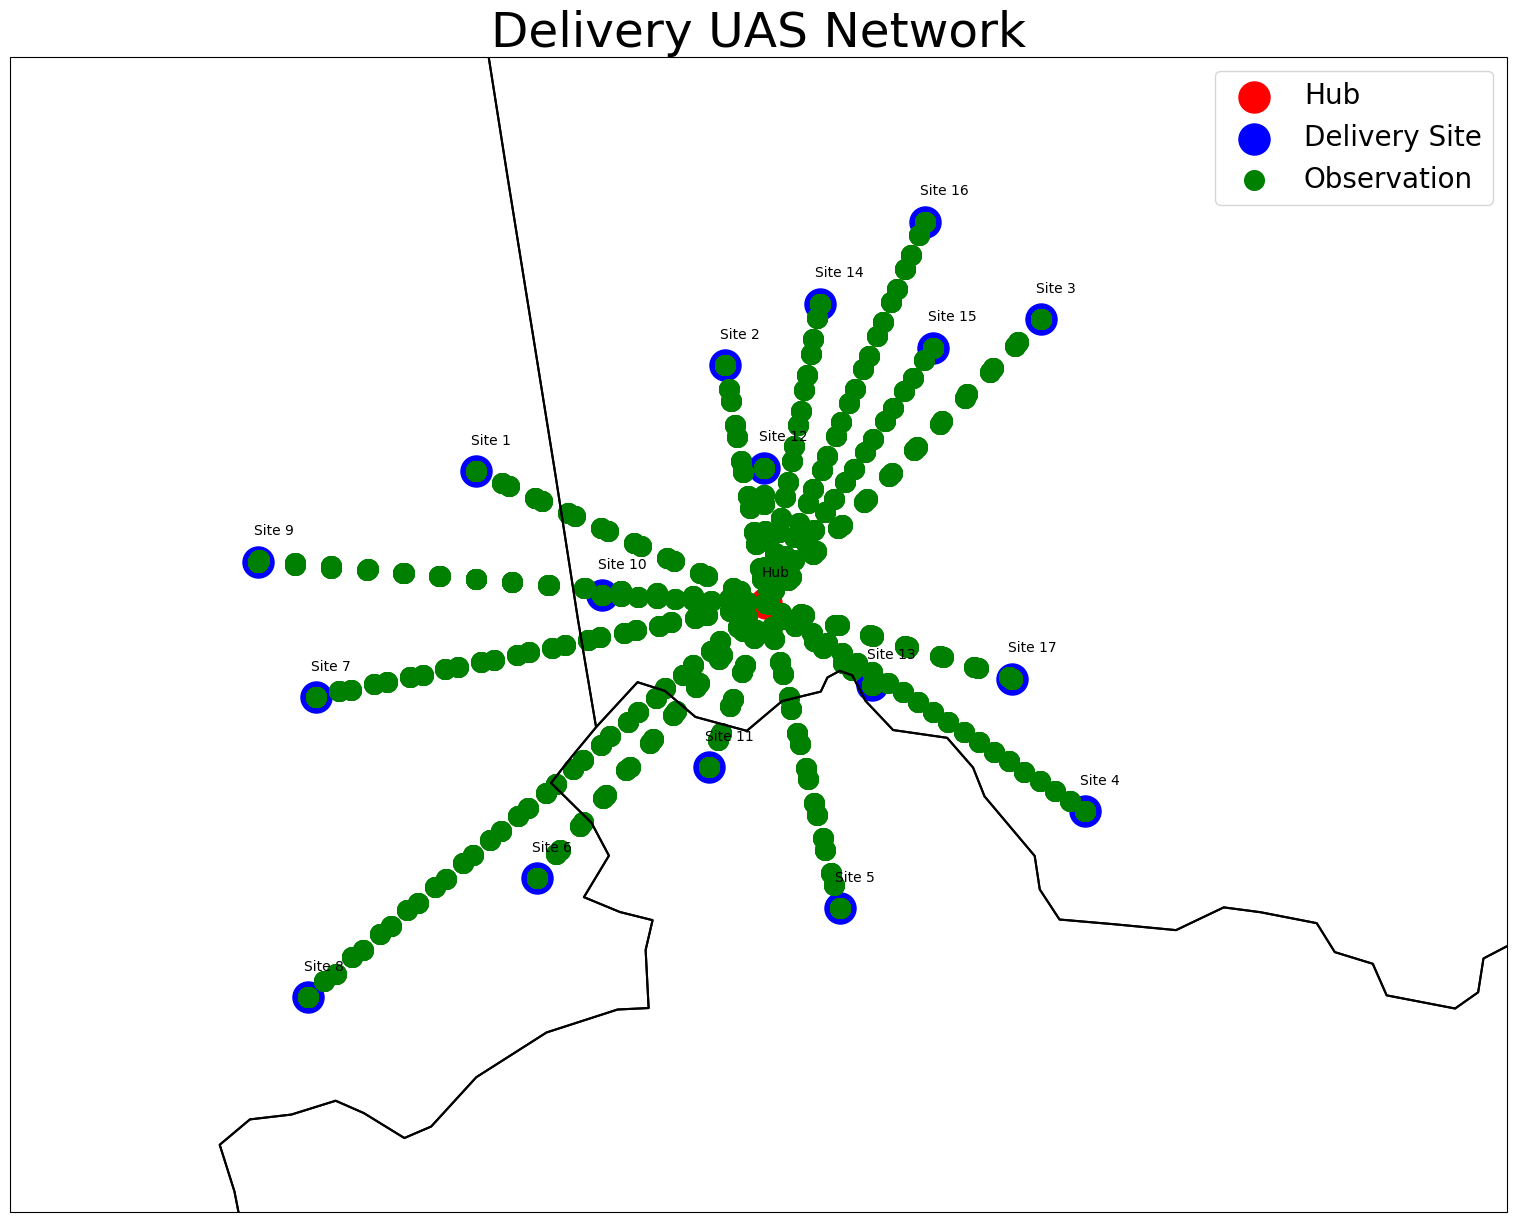

In [10]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.2,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
plt.scatter(lons_start[0], lats_start[0], c='r', s=500, label='Hub', transform=ccrs.PlateCarree())
plt.scatter(lons_end, lats_end, c='b', s=500, label='Delivery Site', transform=ccrs.PlateCarree())
#plt.scatter(path_lon, path_lat, c='g', s=200, transform=ccrs.PlateCarree())
plt.scatter(all_lons1, all_lats1, c='g', s=200, label='Observation', transform=ccrs.PlateCarree())
for i in range(len(lons_end)):
    plt.text(lons_end[i], lats_end[i]+0.03, st_ids[i], transform=ccrs.PlateCarree())
plt.text(lons_start[0], lats_start[0]+0.03, 'Hub', transform=ccrs.PlateCarree())
plt.title('Delivery UAS Network', size=35)
plt.legend(fontsize=20)
#plt.savefig('NewUASNetwork.png', bbox_inches='tight')

In [11]:
print(len(all_lons1)*4)

6144


In [12]:
#Put times in DART format, convert everything to go into the obs_seq file
uas_times2 = (all_times1/86400) + st_day

In [ ]:
#Obs types for the UAS obs. Change once we have this implemented in DART
otype_T = 123
otype_q = 67
otype_u = 121
otype_v = 122

#NOTE: all error values listed here are * squared * (so for an error of 2.0 K, list 4.0 K here)

# #Errors for UAS obs
oerr_T = 0.25
oerr_q = 0.25
oerr_u = 1.0
oerr_v = 1.0

#2X Errors for UAS obs
# oerr_T = 1.0
# oerr_q = 1.0
# oerr_u = 4.0
# oerr_v = 4.0

otype_s = []
obs_s = []
lon_s = []
lat_s = []
elev_s = []
error_s = []
time_s = []

#minute_range = np.arange(180,245,5)
#minute_range = np.arange(595,605,5)

otype_s = []
obs_s = []
lon_s = []
lat_s = []
elev_s = []
error_s = []
time_s = []

minute_range = np.arange(180,545,5)
#minute_range = np.arange(180,240,5)
#minute_range = np.arange(595,605,5)

for mins in minute_range:
    dt_start = datetime(2022,9,15,0,0)
    #dt_start = datetime(2022,7,19,0,0)
    #dt_start = datetime(2021,6,4,0,0)
    
    dt = dt_start + timedelta(minutes=int(mins))
    print(dt)
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP4/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    wrfout = Dataset('/glade/campaign/ral/aap/mawilson/nature_runs/IOP6/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    
    lon = wrfout.variables['XLONG']
    lat = wrfout.variables['XLAT']
    U10 = wrfout.variables['U10']
    V10 = wrfout.variables['U10']
    T2 = np.asarray(wrfout.variables['T2'])*units('K')
    T2F = T2 .to('degF')
    Q2 = np.asarray(wrfout.variables['Q2'])
    P2 = np.asarray(wrfout.variables['PSFC'][:]/100) * units('hPa')
    Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
    cloud=wrfout.variables['QCLOUD']
    T_z = np.asarray(getvar(wrfout, "tk"))
    p_z = np.asarray(getvar(wrfout, "pres"))
    q_zi = np.asarray(wrfout.variables['QVAPOR'][:])
    q_z = specific_humidity_from_mixing_ratio(q_zi)
    u_z, v_z = getvar(wrfout, 'uvmet')
    u_z = np.asarray(u_z)
    v_z = np.asarray(v_z)
    z_z = np.asarray(getvar(wrfout, "height_agl"))
    z_zm = np.asarray(getvar(wrfout, "height"))
    td_z = dewpoint_from_specific_humidity(p_z*units('Pa'), T_z*units('K'), q_z*units('kg/kg')).to('K')
    
    
    #otype = 107
    #otype = 105
    #otype = 106
    #otype = 108
    #otype = 142
    otype_list = [123,67,121,122]
    for otype in otype_list:
        # loc_T2 = location[obstype==otype, :]
        # qc_T2 = qc_new[obstype==otype]
        # obs_T2 = obs_val[obstype==otype, :]
        # lons_T2 = loc_T2[:,0]
        # lats_T2 = loc_T2[:,1]
        # elev_T2 = loc_T2[:,2]
        # time_T2 = times[obstype==otype]
        # lons_T2[lons_T2 > 180] = lons_T2[lons_T2 > 180] - 360
        lons_T2 = all_lons1
        lats_T2 = all_lats1
        elev_T2 = all_zs1
        time_T2 = uas_times2
        
        #Convert WRF file time into same units as the obs_seq time
        dt_tot = (dt - datetime(1601,1,1)).total_seconds() / 86400
        time_diff = np.abs(dt_tot - time_T2)
        
        #Get obs within +- 2.5 minutes of each WRF file
        time_T3 = time_T2[time_diff<(150/86400)]
        lons_T3 = lons_T2[time_diff<(150/86400)]
        lats_T3 = lats_T2[time_diff<(150/86400)]
        elev_T3 = elev_T2[time_diff<(150/86400)]
        
        if len(time_T3)==0:
            print('NO OBS IN WINDOW')
        for k in range(len(lons_T3)):
            latp=lats_T3[k]
            lonp=lons_T3[k]
            #Get location for each ob in model land
            lon1d = np.ndarray.flatten(lon[0,:,:])
            lat1d = np.ndarray.flatten(lat[0,:,:])
            station = []
            points = []
            for i in range(len(lon1d)):
                points.append((lat1d[i],lon1d[i]))
                station.append((latp,lonp))
            dist = haversine.haversine_vector(station,points)
            dist2=dist.reshape(lon.shape[1],lon.shape[2])
            print(lon[0,:,:][np.where(dist2==np.min(dist2))])
            print(lat[0,:,:][np.where(dist2==np.min(dist2))])
            print(np.where(dist2==np.min(dist2)))
            st_xind = np.where(dist2==np.min(dist2))[0][0]
            st_yind = np.where(dist2==np.min(dist2))[1][0]
            print(elev_T3[k], 'elev')

            
            if otype == 123:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[T_z[0,st_xind,st_yind]],T_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                # #Fix height of sfc points to 2m
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                print(elev_T3[k], p_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_T))
                if np.abs(error/4) > (np.sqrt(oerr_T)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_T)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_T

            if otype == 67:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[td_z[0,0,st_xind,st_yind]],td_z[0,:,st_xind,st_yind]]).magnitude
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_q))
                if np.abs(error/4) > (np.sqrt(oerr_q)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_q)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_q*4
                
            elif otype == 121:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[u_z[0,st_xind,st_yind]],u_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_u))
                if np.abs(error/4) > (np.sqrt(oerr_u)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_u)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_u
                
            elif otype == 122:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[v_z[0,st_xind,st_yind]],v_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_v))
                if np.abs(error/4) > (np.sqrt(oerr_v)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_v)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_v
            
            if np.isnan(T2_a):
                #If the observation is a nan or outside of the the interpolation bounds, skip it
                print('skipping nan ob')
                continue
        
            #Append obs to arrays for writing to obs_seq file later
            otype_s.append(otype)
            obs_s.append(T2_b)
            lon_s.append(lonp)
            lat_s.append(latp)
            elev_s.append(elev_T3[k]+z_zmpoint)
            time_s.append(time_T3[k])
            error_s.append(error_a)
            print('elevation',elev_T3[k]+z_zmpoint)

2022-09-15 03:00:00
[-84.55058]
[39.20955]
(array([540]), array([683]))
0.0 elev
0.0 [98716.5    98716.5    98341.734  97969.34   97586.555  97186.16
 96761.46   96299.71   95796.42   95242.63   94628.86   93952.01
 93200.27   92364.086  91442.51   90426.01   89297.97   88057.95
 86693.12   85191.42   83549.5    81751.39   79790.07   77651.93
 75328.16   72809.76   70086.75   67154.914  64016.855  60671.3
 57124.188  53385.7    49472.754  45406.51   41216.715  36942.395
 32636.355  28363.887  24207.668  20262.014  16622.193  13354.887
 10494.854   8039.8926  5955.512 ] [294.52298 294.52298 295.07333 294.9477  294.82986 294.62262 294.4045
 294.21582 294.04373 293.87875 293.70374 293.45828 293.08377 292.58044
 291.99207 291.3124  290.60648 289.8195  288.79776 287.54483 287.43643
 288.14896 287.27487 285.36682 283.13712 280.87457 278.8939  276.9342
 275.0416  272.5392  269.55774 266.23065 262.3135  257.8136  252.33315
 246.20137 238.61064 230.60953 223.23872 220.03429 216.90009 212.28682


/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-84.55058]
[39.20955]
(array([540]), array([683]))
0.0 elev
0.0 [98867.48   98867.48   98486.33   98121.79   97730.484  97330.87
 96910.01   96442.32   95938.64   95381.1    94767.8    94085.22
 93334.57   92500.57   91575.625  90557.3    89427.46   88183.21
 86813.58   85308.734  83659.516  81857.73   79890.94   77747.94
 75417.984  72890.52   70160.18   67222.664  64077.38   60724.414
 57170.773  53425.52   49505.863  45433.113  41236.25   36955.39
 32643.744  28368.479  24209.916  20263.713  16622.389  13354.257
 10494.142   8038.6577  5955.393 ] [292.80664 292.80664 294.39633 294.5943  294.55    294.25894 293.8838
 293.48016 293.12344 292.88287 292.6365  292.27213 291.8456  291.42722
 291.0483  290.61353 290.03918 289.1595  288.00354 287.4204  288.16248
 287.2138  286.20395 284.80817 282.92642 280.76205 278.242   276.9405
 275.42755 273.09738 270.47995 267.2457  263.51932 259.11414 253.31898
 246.52853 238.73262 230.77045 223.18843 218.86368 215.7475  211.09956
 207.0368  208.2055

/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-84.59293]
[39.23276]
(array([563]), array([650]))
100.0 elev
100.0 [98816.1    98816.1    98444.836  98066.055  97689.68   97286.625
 96861.445  96400.86   95896.52   95341.18   94725.22   94045.125
 93291.664  92456.57   91531.12   90511.984  89384.836  88141.82
 86771.67   85265.64   83620.95   81820.06   79853.74   77711.93
 75383.03   72860.68   70130.98   67196.74   64053.137  60702.934
 57151.418  53409.22   49491.008  45420.082  41225.61   36948.1
 32637.596  28363.367  24205.158  20259.852  16620.441  13352.359
 10492.056   8038.517   5953.6094] [292.14114 292.14114 294.11575 294.57785 294.64526 294.4655  294.12598
 293.69574 293.256   292.87836 292.58337 292.27216 291.89093 291.50745
 291.14243 290.6859  290.00275 288.85617 287.59473 287.2479  287.8266
 287.25116 286.18857 284.8122  282.92484 280.64624 278.2229  277.11993
 275.67352 273.1299  270.42142 267.2729  263.5457  259.07886 253.34644
 246.52724 238.67453 230.71945 222.98708 218.77327 215.95155 211.29582
 206.97638 20

In [ ]:
print(t_point)
print(z_point)

In [ ]:
print(len(time_T2))
print(len(lons_T2))
print(len(all_lons1))
print(len(all_times1))

In [ ]:
#Convert lats and lons to radians for DART, because why not
lon_DART = np.radians(np.asarray(lon_s))
lat_DART = np.radians(np.asarray(lat_s))

lon_DART = np.where(lon_DART > 0.0, lon_DART, lon_DART+(2.0*np.pi))

#Convert time into DART format. This is hacky now, improve later
day_DART = 154024
#day_DART = 153966
#day_DART = 153556
seconds_DART = (np.asarray(time_s) - day_DART) * 86400

In [ ]:
#Sort everything in time order
inds_time = seconds_DART.argsort()
# print(seconds_DART)
# print(seconds_DART[inds_time])
seconds_DART1 = seconds_DART[inds_time]
seconds_DART1[seconds_DART1 < 0] = 0
obs_s1 = np.asarray(obs_s)[inds_time]
lon_DART1 = lon_DART[inds_time]
lat_DART1 = lat_DART[inds_time]
elev_s1 = np.asarray(elev_s)[inds_time]
otype_s1 = np.asarray(otype_s)[inds_time]
error_s1 = np.asarray(error_s)[inds_time]

In [ ]:
for bigfoot in [1,2]:
    print(bigfoot)
    #Write the simulated obs out to an obs_seq file
    filename = 'SIM_DELIVERYUAS_IOP6_FIXEDERR'
    fi = open(filename, "w")
    fi.write(" obs_sequence\n")
    fi.write("obs_kind_definitions\n")
    fi.write("    %d \n" %(4))
    fi.write("    %d          %s   \n" %(123, 'UAS_TEMPERATURE'))
    fi.write("    %d          %s   \n" %(67, 'UAS_DEWPOINT'))
    fi.write("    %d          %s   \n" %(121, 'UAS_U_WIND_COMPONENT'))
    fi.write("    %d          %s   \n" %(122, 'UAS_V_WIND_COMPONENT'))
    
    fi.write("  num_copies:            %d  num_qc:            %d\n" % (1,1))
    fi.write(" num_obs:       %d  max_num_obs:       %d\n" % (len(obs_s1), len(obs_s1)))
    fi.write("MADIS observation\n")
    fi.write("Data QC\n")
    
    fi.write("  first:            %d  last:       %d\n" % (1, len(obs_s1)))
    
    for q in range(len(obs_s1)):
    
        fi.write(" OBS            %d\n" % (q+1) )
        fi.write("   %20.14f\n" % obs_s1[q] )
        fi.write("   %20.14f\n" % 1.0 )
    
        if q+1 == 1:
            fi.write(" %d %d %d\n" % (-1, q+2, -1) ) #First obs
        elif q+1 == len(obs_s1):
            fi.write(" %d %d %d\n" % (q, -1, -1) ) #Last obs
        else:
            fi.write(" %d %d %d\n" % (q, q+2, -1) )
    
        fi.write("obdef\n")
        fi.write("loc3d\n")
        fi.write("    %20.14f          %20.14f          %20.14f     %d\n" %
                           (lon_DART1[q], lat_DART1[q], elev_s1[q], 3))
        fi.write("kind\n")
    
        fi.write("     %d     \n" % otype_s1[q])
    
        fi.write("    %d          %d     \n" % (seconds_DART1[q], day_DART))
    
        fi.write("    %20.14f  \n" % error_s1[q])

In [ ]:
print(otype_s)